# Hierarchical Models for Firing Rates & Amplitudes

This notebook loads **wide-format** block-level data (one row per subject, columns = BL + Block_1 … Block_30) and fits **hierarchical linear mixed-effects models** (LMM) with a random intercept per subject.

### Data convention
- **BL** = baseline (pre-stimulation)
- **Odd blocks** (1, 3, 5, …) = stimulation
- **Even blocks** (2, 4, 6, …) = pause

### Models
1. **Block-type effect** – does stimulation change the DV compared to (a) all non-stim epochs, (b) pause-only epochs?
2. **Time effect** – does the DV change across blocks (linear trend)?
3. **Immediate effect** – percent change relative to the previous block.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style='white', context='talk')

print('Setup done.')

Setup done.


## 1. Load & reshape data

In [2]:
# ── paths ──────────────────────────────────────────────────────
RATE_PATH = r'final_firing_rates_wide.csv'
AMP_PATH  = r'final_amplitudes_wide.csv'


def load_and_melt(path, value_name):
    """
    Load a wide CSV (rows=subjects, cols=BL,Block_1…Block_30)
    and convert it to long format with columns:
        subject_id, block_label, block_number, block_type, value
    """
    df = pd.read_csv(path)
    # identify block columns (everything except Subject_ID)
    block_cols = [c for c in df.columns if c != 'Subject_ID']

    long = df.melt(id_vars='Subject_ID',
                   value_vars=block_cols,
                   var_name='block_label',
                   value_name=value_name)

    # drop missing observations
    long = long.dropna(subset=[value_name]).copy()

    # assign block number (BL → 0, Block_k → k)
    long['block_number'] = long['block_label'].apply(
        lambda x: 0 if x == 'BL' else int(x.split('_')[1])
    )

    # assign block type
    def _type(label):
        if label == 'BL':
            return 'baseline'
        num = int(label.split('_')[1])
        return 'stim' if num % 2 == 1 else 'pause'

    long['block_type'] = long['block_label'].apply(_type)

    # ensure subject is string (for grouping)
    long['Subject_ID'] = long['Subject_ID'].astype(str)

    long = long.sort_values(['Subject_ID', 'block_number']).reset_index(drop=True)
    return long


df_rate = load_and_melt(RATE_PATH, 'firing_rate')
df_amp  = load_and_melt(AMP_PATH,  'amplitude')

print(f'Firing-rate long shape : {df_rate.shape}')
print(f'Amplitude   long shape : {df_amp.shape}')
display(df_rate.head(10))

Firing-rate long shape : (172, 5)
Amplitude   long shape : (171, 5)


,Subject_ID,block_label,firing_rate,block_number,block_type
0,485,BL,12.610973,0,baseline
1,485,Block_1,5.796996,1,stim
2,485,Block_2,7.005146,2,pause
3,485,Block_3,2.921098,3,stim
4,485,Block_4,2.064271,4,pause
5,485,Block_5,3.434616,5,stim
6,485,Block_6,7.596021,6,pause
7,485,Block_7,4.700520,7,stim
8,485,Block_8,3.400000,8,pause
9,486,BL,6.167572,0,baseline


In [3]:
# quick sanity: subjects × block types
for label, df in [('Firing Rate', df_rate), ('Amplitude', df_amp)]:
    print(f'\n── {label} ──')
    print(df.groupby('block_type')['Subject_ID'].nunique())
    print(f'Total observations: {len(df)}')


── Firing Rate ──
block_type
baseline    10
pause       12
stim        12
Name: Subject_ID, dtype: int64
Total observations: 172

── Amplitude ──
block_type
baseline    10
pause       12
stim        12
Name: Subject_ID, dtype: int64
Total observations: 171


---
## 2. Helper: run & display a MixedLM

In [4]:
def fit_lmm(formula, data, groups_col='Subject_ID', reml=True):
    """
    Fit a linear mixed-effects model with random intercept per subject.
    Returns the fitted result.
    """
    model = smf.mixedlm(formula, data=data, groups=data[groups_col])
    result = model.fit(reml=reml)
    return result


def print_model(result, title=''):
    """Pretty-print a model summary."""
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(result.summary())
    print()


def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

---
## 3. Model 1 – Effect of Block Type

### 1A: Stim vs. Non-Stim (baseline + pause combined)
A binary contrast: **stim** blocks vs all **non-stim** epochs (BL + pause).

### 1B: Stim vs. Pause only
Exclude baseline entirely; compare **stim** blocks to **pause** blocks.

In [5]:
def run_block_type_models(df, dv, label):
    """
    Run block-type models on a long dataframe.
    dv : name of the dependent-variable column
    label : human-readable label (e.g. 'Firing Rate')
    """
    results = {}

    # ── 1A  stim vs non-stim ─────────────────────────────────────
    df_1a = df.copy()
    df_1a['is_stim'] = (df_1a['block_type'] == 'stim').astype(int)

    formula_1a = f'{dv} ~ is_stim'
    res_1a = fit_lmm(formula_1a, df_1a)
    print_model(res_1a,
                f'{label} – Model 1A: Stim vs Non-Stim (BL + Pause)')
    results['1A'] = res_1a

    # ── 1B  stim vs pause only ───────────────────────────────────
    df_1b = df[df['block_type'].isin(['stim', 'pause'])].copy()
    df_1b['is_stim'] = (df_1b['block_type'] == 'stim').astype(int)

    formula_1b = f'{dv} ~ is_stim'
    res_1b = fit_lmm(formula_1b, df_1b)
    print_model(res_1b,
                f'{label} – Model 1B: Stim vs Pause Only')
    results['1B'] = res_1b

    return results

In [6]:
rate_m1 = run_block_type_models(df_rate, 'firing_rate', 'Firing Rate')

Firing Rate – Model 1A: Stim vs Non-Stim (BL + Pause)
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate
No. Observations: 172     Method:             REML       
No. Groups:       12      Scale:              20.3046    
Min. group size:  9       Log-Likelihood:     -524.6143  
Max. group size:  31      Converged:          Yes        
Mean group size:  14.3                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       9.126    2.935  3.109 0.002  3.373 14.878
is_stim        -1.803    0.689 -2.618 0.009 -3.153 -0.453
Group Var     100.486    9.917                           


Firing Rate – Model 1B: Stim vs Pause Only
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate
No. Observations: 162     Method:             REML 

In [7]:
amp_m1 = run_block_type_models(df_amp, 'amplitude', 'Amplitude')

Amplitude – Model 1A: Stim vs Non-Stim (BL + Pause)
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude
No. Observations: 171     Method:             REML     
No. Groups:       12      Scale:              0.4861   
Min. group size:  9       Log-Likelihood:     -202.4756
Max. group size:  31      Converged:          Yes      
Mean group size:  14.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     3.218    0.323  9.954 0.000  2.584  3.851
is_stim      -0.236    0.107 -2.207 0.027 -0.445 -0.026
Group Var     1.184    0.772                           


Amplitude – Model 1B: Stim vs Pause Only
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude
No. Observations: 161     Method:             REML     
No. Groups:       12      S

### Visualisations – Block-Type Effect

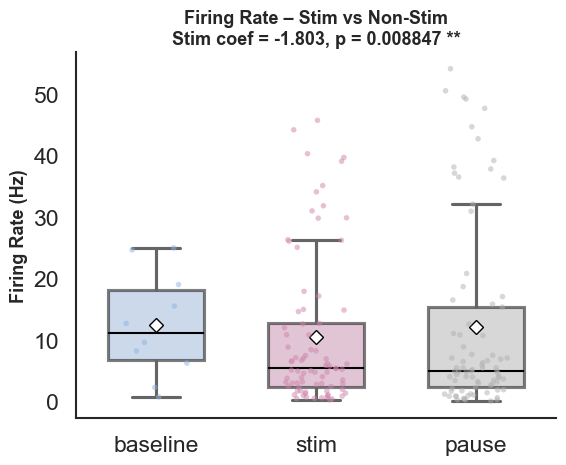

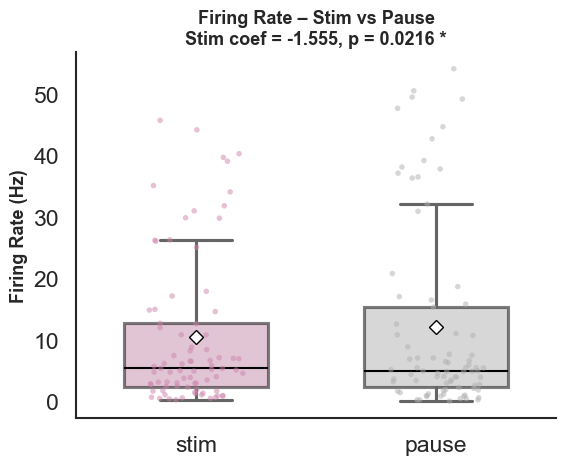

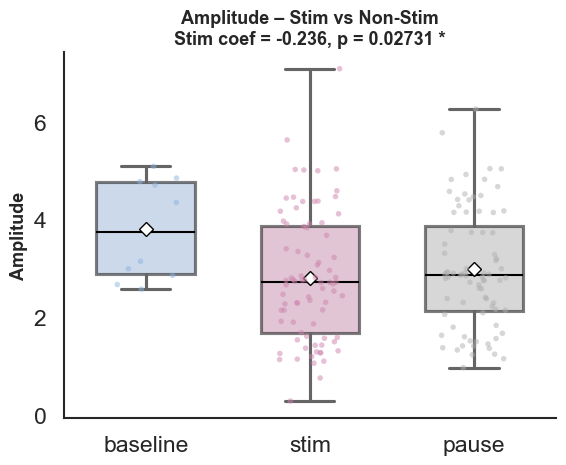

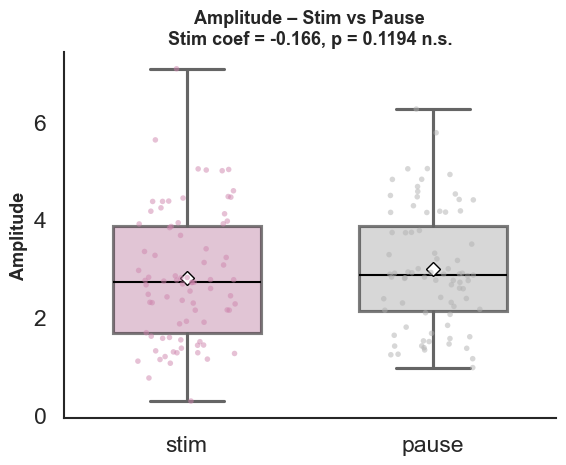

In [8]:
def plot_block_type(df, dv, label, model_result, title='', exclude_baseline=False):
    """Box + strip plot for stim vs non-stim."""
    data = df.copy()
    if exclude_baseline:
        data = data[data['block_type'] != 'baseline']
    
    fig, ax = plt.subplots(figsize=(6, 5))

    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0', 'baseline': '#8db4e2'}
    order = ['baseline', 'stim', 'pause'] if not exclude_baseline else ['stim', 'pause']
    
    sns.boxplot(
        data=data, x='block_type', y=dv, order=order,
        palette=palette, width=0.6, showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'white',
                   'markeredgecolor': 'black', 'markersize': 7},
        boxprops=dict(alpha=0.5, edgecolor='black'),
        medianprops=dict(color='black', linewidth=1.5),
        showfliers=False, zorder=2, ax=ax
    )
    sns.stripplot(
        data=data, x='block_type', y=dv, order=order,
        palette=palette, size=4, alpha=0.5,
        linewidth=0, zorder=3, ax=ax, jitter=0.2
    )

    # p-value from is_stim coefficient
    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\nStim coef = {coef:.3f}, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')

    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=13, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


# Firing Rate
plot_block_type(df_rate, 'firing_rate', 'Firing Rate (Hz)',
                rate_m1['1A'], 'Firing Rate – Stim vs Non-Stim')

plot_block_type(df_rate, 'firing_rate', 'Firing Rate (Hz)',
                rate_m1['1B'], 'Firing Rate – Stim vs Pause',
                exclude_baseline=True)

# Amplitude
plot_block_type(df_amp, 'amplitude', 'Amplitude',
                amp_m1['1A'], 'Amplitude – Stim vs Non-Stim')

plot_block_type(df_amp, 'amplitude', 'Amplitude',
                amp_m1['1B'], 'Amplitude – Stim vs Pause',
                exclude_baseline=True)

---
## 4. Model 2 – Effect of Time

Linear effect of `block_number` on the DV, with optional interaction with `block_type`.

### 2A: Overall time trend (all blocks)
### 2B: Time trend with block-type interaction (stim & pause only)

In [9]:
def run_time_models(df, dv, label):
    """
    Run time-effect models.
    """
    results = {}

    # ── 2A  overall linear time trend ────────────────────────────
    formula_2a = f'{dv} ~ block_number'
    res_2a = fit_lmm(formula_2a, df)
    print_model(res_2a,
                f'{label} – Model 2A: Linear Time Trend (all blocks)')
    results['2A'] = res_2a

    # ── 2B  time × block_type interaction (stim & pause only) ───
    df_2b = df[df['block_type'].isin(['stim', 'pause'])].copy()
    df_2b['is_stim'] = (df_2b['block_type'] == 'stim').astype(int)

    formula_2b = f'{dv} ~ block_number * is_stim'
    res_2b = fit_lmm(formula_2b, df_2b)
    print_model(res_2b,
                f'{label} – Model 2B: Time × Block-Type Interaction')
    results['2B'] = res_2b

    return results

In [10]:
rate_m2 = run_time_models(df_rate, 'firing_rate', 'Firing Rate')

Firing Rate – Model 2A: Linear Time Trend (all blocks)
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: firing_rate
No. Observations: 172     Method:             REML       
No. Groups:       12      Scale:              20.4870    
Min. group size:  9       Log-Likelihood:     -528.0614  
Max. group size:  31      Converged:          Yes        
Mean group size:  14.3                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       9.210    3.035  3.034 0.002  3.260 15.159
block_number   -0.135    0.062 -2.173 0.030 -0.258 -0.013
Group Var     106.724   10.503                           


Firing Rate – Model 2B: Time × Block-Type Interaction
             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   firing_rate
No. Observations:    162     

In [11]:
amp_m2 = run_time_models(df_amp, 'amplitude', 'Amplitude')

Amplitude – Model 2A: Linear Time Trend (all blocks)
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: amplitude
No. Observations: 171     Method:             REML     
No. Groups:       12      Scale:              0.4750   
Min. group size:  9       Log-Likelihood:     -202.7608
Max. group size:  31      Converged:          Yes      
Mean group size:  14.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     3.304    0.317 10.409 0.000  2.682  3.927
block_number -0.029    0.010 -3.046 0.002 -0.048 -0.010
Group Var     1.120    0.741                           


Amplitude – Model 2B: Time × Block-Type Interaction
             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   amplitude
No. Observations:     161       Method:               REML 

### Visualisations – Time Effect

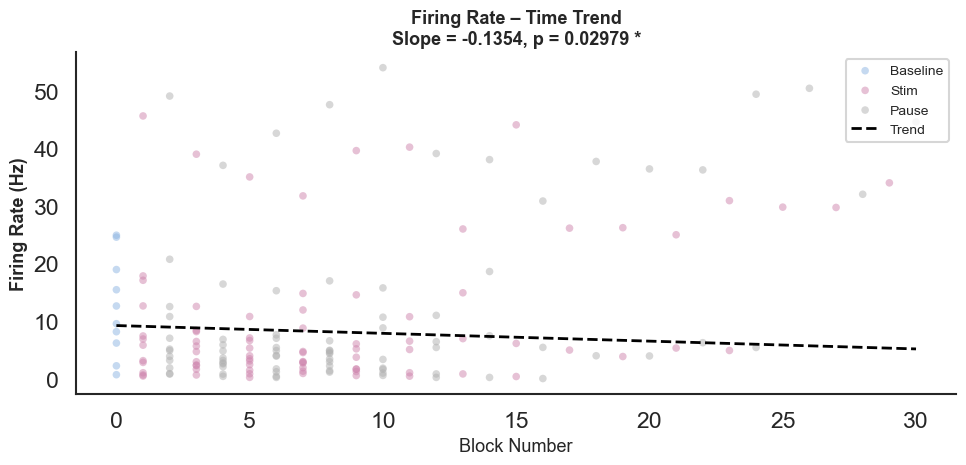

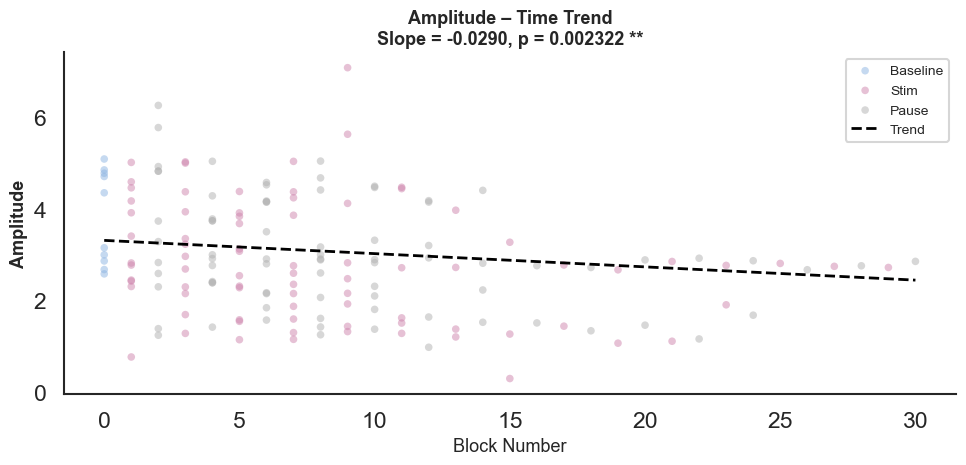

In [12]:
def plot_time_trend(df, dv, label, model_result, title=''):
    """Scatter + regression line per block type across time."""
    data = df.copy()

    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0', 'baseline': '#8db4e2'}

    fig, ax = plt.subplots(figsize=(10, 5))

    for bt in ['baseline', 'stim', 'pause']:
        subset = data[data['block_type'] == bt]
        if subset.empty:
            continue
        ax.scatter(subset['block_number'], subset[dv],
                   c=palette.get(bt, 'gray'), alpha=0.5,
                   label=bt.capitalize(), s=30, edgecolors='none')

    # overall trend line from the model
    x_range = np.linspace(data['block_number'].min(),
                          data['block_number'].max(), 100)
    intercept = model_result.fe_params['Intercept']
    slope = model_result.fe_params.get('block_number', 0)
    ax.plot(x_range, intercept + slope * x_range,
            color='black', linewidth=2, linestyle='--', label='Trend')

    p = model_result.pvalues.get('block_number', np.nan)
    ax.set_title(f'{title}\nSlope = {slope:.4f}, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Block Number', fontsize=13)
    ax.set_ylabel(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_time_trend(df_rate, 'firing_rate', 'Firing Rate (Hz)',
                rate_m2['2A'], 'Firing Rate – Time Trend')

plot_time_trend(df_amp, 'amplitude', 'Amplitude',
                amp_m2['2A'], 'Amplitude – Time Trend')

---
## 5. Model 3 – Immediate Effect (Percent Change from Previous Block)

For each subject, compute the **percent change** of each block relative to the **preceding** block:

$$\text{pct\_change}_i = \frac{\text{value}_i - \text{value}_{i-1}}{\text{value}_{i-1}} \times 100$$

Then test whether these percent changes differ by block type (stim vs pause).

In [13]:
def compute_pct_change(df, dv):
    """
    Within each subject, compute % change from the previous block.
    Returns a new dataframe with an extra 'pct_change' column.
    The first block of each subject is dropped (no previous value).
    """
    out = df.sort_values(['Subject_ID', 'block_number']).copy()
    out['prev_value'] = out.groupby('Subject_ID')[dv].shift(1)
    out['pct_change'] = ((out[dv] - out['prev_value']) / out['prev_value']) * 100
    out = out.dropna(subset=['pct_change']).copy()
    # remove infinite values (division by zero if prev_value == 0)
    out = out[np.isfinite(out['pct_change'])].copy()
    return out


df_rate_pct = compute_pct_change(df_rate, 'firing_rate')
df_amp_pct  = compute_pct_change(df_amp,  'amplitude')

print(f'Firing-rate pct-change obs: {len(df_rate_pct)}')
print(f'Amplitude   pct-change obs: {len(df_amp_pct)}')
display(df_rate_pct.head(10))

Firing-rate pct-change obs: 160
Amplitude   pct-change obs: 159


,Subject_ID,block_label,firing_rate,block_number,block_type,prev_value,pct_change
1,485,Block_1,5.796996,1,stim,12.610973,-54.032124
2,485,Block_2,7.005146,2,pause,5.796996,20.840950
3,485,Block_3,2.921098,3,stim,7.005146,-58.300682
4,485,Block_4,2.064271,4,pause,2.921098,-29.332349
5,485,Block_5,3.434616,5,stim,2.064271,66.383964
6,485,Block_6,7.596021,6,pause,3.434616,121.160683
7,485,Block_7,4.700520,7,stim,7.596021,-38.118656
8,485,Block_8,3.400000,8,pause,4.700520,-27.667576
10,486,Block_1,0.617497,1,stim,6.167572,-89.988002
11,486,Block_2,1.843256,2,pause,0.617497,198.504369


In [14]:
def run_immediate_effect_models(df_pct, label):
    """
    Models on the pct_change variable.
    3A: Is % change different from zero overall?
    3B: Does % change differ between stim and pause blocks?
    3C: Does % change differ between stim and pause, with time interaction?
    """
    results = {}

    # ── 3A  overall pct change ───────────────────────────────────
    # intercept-only → tests whether mean pct_change ≠ 0
    res_3a = fit_lmm('pct_change ~ 1', df_pct)
    print_model(res_3a,
                f'{label} – Model 3A: Overall Pct Change ≠ 0?')
    results['3A'] = res_3a

    # ── 3B  stim vs pause (exclude baseline transitions) ────────
    df_3b = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    df_3b['is_stim'] = (df_3b['block_type'] == 'stim').astype(int)

    res_3b = fit_lmm('pct_change ~ is_stim', df_3b)
    print_model(res_3b,
                f'{label} – Model 3B: Pct Change Stim vs Pause')
    results['3B'] = res_3b

    # ── 3C  stim vs pause with time interaction ──────────────────
    res_3c = fit_lmm('pct_change ~ is_stim * block_number', df_3b)
    print_model(res_3c,
                f'{label} – Model 3C: Pct Change ~ BlockType × Time')
    results['3C'] = res_3c

    return results

In [15]:
rate_m3 = run_immediate_effect_models(df_rate_pct, 'Firing Rate')

Firing Rate – Model 3A: Overall Pct Change ≠ 0?
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 160     Method:             REML      
No. Groups:       12      Scale:              7597.1815 
Min. group size:  8       Log-Likelihood:     -938.5237 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.3                                  
---------------------------------------------------------
           Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  16.494     8.191  2.014  0.044   0.441  32.547
Group Var   0.000     6.797                              

Firing Rate – Model 3B: Pct Change Stim vs Pause
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 160     Method:             REML      
No. Groups:       12      Scale:              7645.0892 
Min. 

In [16]:
amp_m3 = run_immediate_effect_models(df_amp_pct, 'Amplitude')

Amplitude – Model 3A: Overall Pct Change ≠ 0?
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 159     Method:             REML      
No. Groups:       12      Scale:              1051.4012 
Min. group size:  8       Log-Likelihood:     -776.3992 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.2                                  
---------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   1.660     2.565  0.647  0.517  -3.367   6.687
Group Var   0.000                                        

Amplitude – Model 3B: Pct Change Stim vs Pause
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 159     Method:             REML      
No. Groups:       12      Scale:              968.1782  
Min. grou

### Visualisations – Immediate (Percent Change) Effect

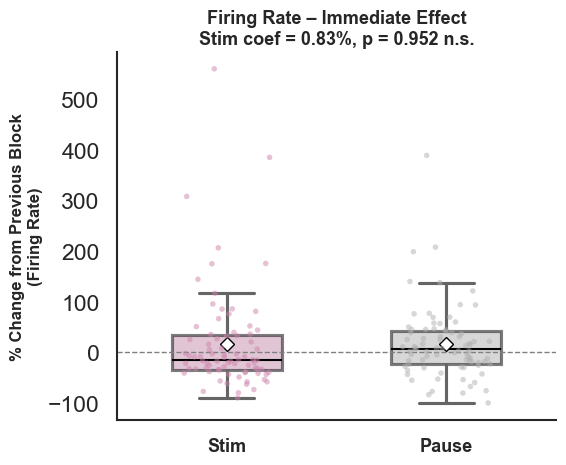

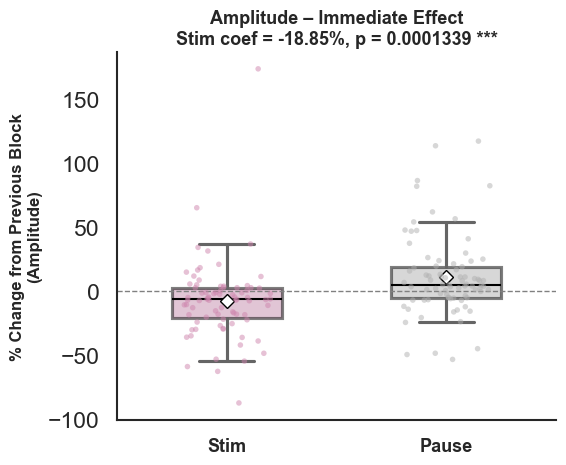

In [17]:
def plot_pct_change(df_pct, label, model_result, title=''):
    """Box + strip plot of pct_change by block type (stim vs pause)."""
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()

    fig, ax = plt.subplots(figsize=(6, 5))
    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

    sns.boxplot(
        data=data, x='block_type', y='pct_change',
        order=['stim', 'pause'], palette=palette,
        width=0.5, showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'white',
                   'markeredgecolor': 'black', 'markersize': 7},
        boxprops=dict(alpha=0.5, edgecolor='black'),
        medianprops=dict(color='black', linewidth=1.5),
        showfliers=False, zorder=2, ax=ax
    )
    sns.stripplot(
        data=data, x='block_type', y='pct_change',
        order=['stim', 'pause'], palette=palette,
        size=4, alpha=0.5, linewidth=0, zorder=3, ax=ax, jitter=0.2
    )

    ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=1)

    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\nStim coef = {coef:.2f}%, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Stim', 'Pause'], fontsize=13, fontweight='bold')
    ax.set_ylabel(f'% Change from Previous Block\n({label})',
                  fontsize=12, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_pct_change(df_rate_pct, 'Firing Rate',
                rate_m3['3B'], 'Firing Rate – Immediate Effect')

plot_pct_change(df_amp_pct, 'Amplitude',
                amp_m3['3B'], 'Amplitude – Immediate Effect')

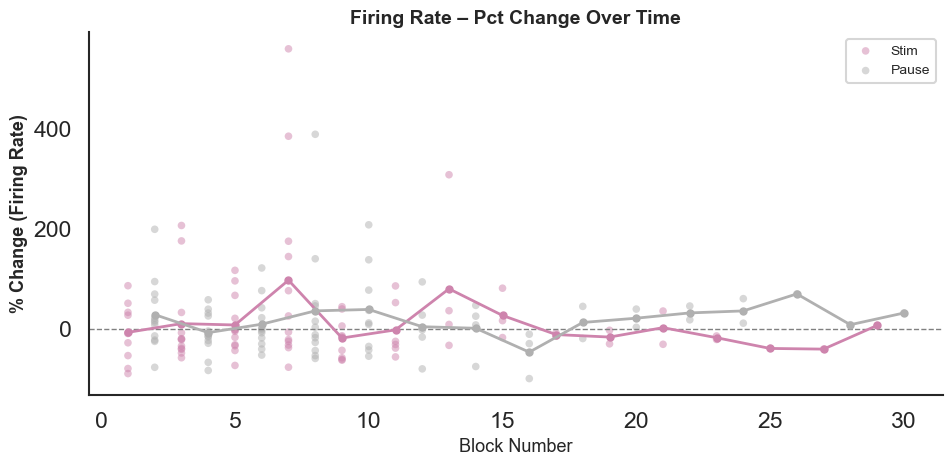

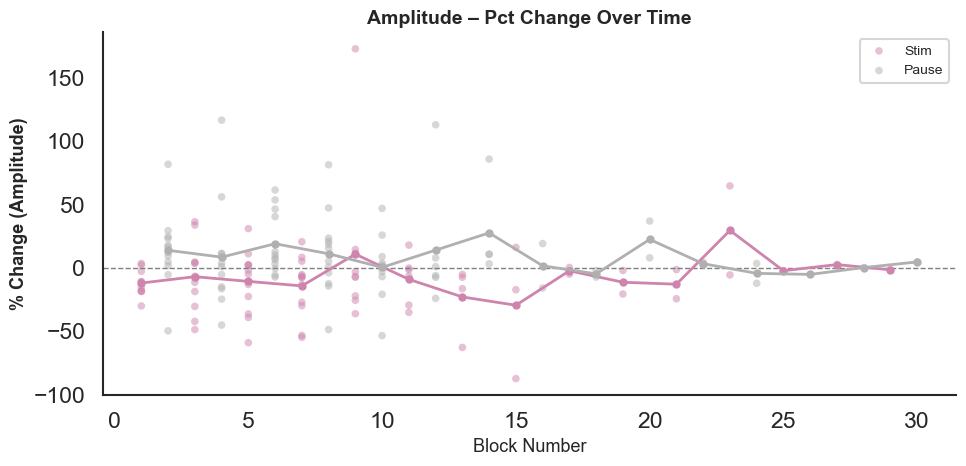

In [18]:
def plot_pct_over_time(df_pct, label, title=''):
    """Pct change scatter across block number, colored by block type."""
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()

    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

    fig, ax = plt.subplots(figsize=(10, 5))
    for bt in ['stim', 'pause']:
        sub = data[data['block_type'] == bt]
        ax.scatter(sub['block_number'], sub['pct_change'],
                   c=palette[bt], label=bt.capitalize(),
                   alpha=0.5, s=30, edgecolors='none')

    # per-type mean at each block number
    for bt, color in palette.items():
        means = data[data['block_type'] == bt].groupby('block_number')['pct_change'].mean()
        ax.plot(means.index, means.values, color=color,
                linewidth=2, marker='o', markersize=5)

    ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Block Number', fontsize=13)
    ax.set_ylabel(f'% Change ({label})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_pct_over_time(df_rate_pct, 'Firing Rate',
                   'Firing Rate – Pct Change Over Time')

plot_pct_over_time(df_amp_pct, 'Amplitude',
                   'Amplitude – Pct Change Over Time')

In [31]:
df_amp_pct.

,Subject_ID,block_label,amplitude,block_number,block_type,prev_value,pct_change
1,485,Block_1,3.397493,1,stim,4.844971,-29.875885
2,485,Block_2,3.726531,2,pause,3.397493,9.684734
3,485,Block_3,4.994247,3,stim,3.726531,34.018656
4,485,Block_4,3.772729,4,pause,4.994247,-24.458502
5,485,Block_5,2.303360,5,stim,3.772729,-38.947102
...,...,...,...,...,...,...,...
166,545,Block_6,4.165183,6,pause,3.905629,6.645644
167,545,Block_7,5.031972,7,stim,4.165183,20.810349
168,545,Block_8,2.591881,8,pause,5.031972,-48.491745
169,545,Block_9,7.080193,9,stim,2.591881,173.168149


---
## 5b. Model 3B – Advanced Comparative Visualizations

Additional plots for the *immediate-effect* analysis (Model 3B):

1. **Distribution (KDE + histogram)** of per-block % change, split by stim vs pause.
2. **Paired box-and-line plot** – raw DV values for each pair of consecutive blocks
   (stim → following pause, or baseline → first stim), with connecting lines
   so individual-subject trends are visible.
3. **Cumulative % change trajectory** – per-subject cumulative sum of pct-change
   across blocks, coloured by block type, to reveal long-term drift.

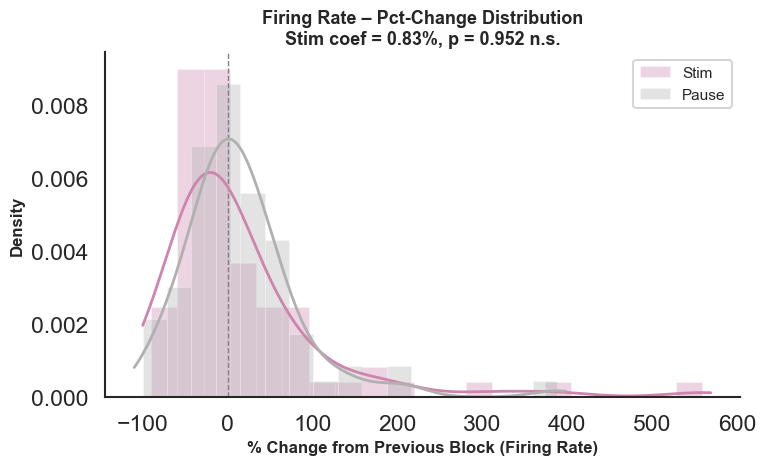

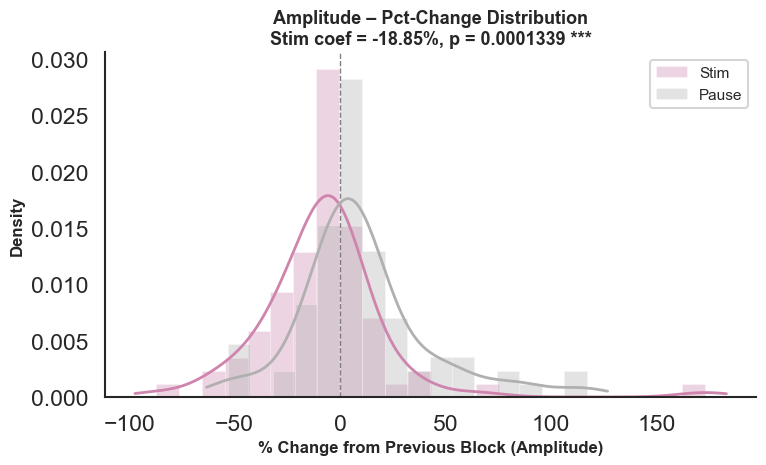

In [28]:
# ── 5b-1  Distribution of Pct Change: Stim vs Pause ──────────────
from scipy.stats import gaussian_kde

def plot_pct_distribution(df_pct, label, model_result, title=''):
    """KDE + histogram of pct_change, split by block type.
    Pure matplotlib + scipy to avoid seaborn OptionError.
    """
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

    fig, ax = plt.subplots(figsize=(8, 5))
    for bt in ['stim', 'pause']:
        subset = data[data['block_type'] == bt]['pct_change'].dropna().values
        if len(subset) < 2:
            continue
        # histogram
        ax.hist(subset, bins='auto', density=True, alpha=0.35,
                color=palette[bt], edgecolor='white', linewidth=0.5,
                label=bt.capitalize())
        # KDE via scipy
        kde = gaussian_kde(subset)
        x_grid = np.linspace(subset.min() - 10, subset.max() + 10, 300)
        ax.plot(x_grid, kde(x_grid), color=palette[bt], linewidth=2)

    ax.axvline(0, color='gray', linewidth=1, linestyle='--', zorder=1)

    # annotate with model 3B stats
    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\nStim coef = {coef:.2f}%, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(f'% Change from Previous Block ({label})',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.legend(fontsize=11)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_pct_distribution(df_rate_pct, 'Firing Rate',
                      rate_m3['3B'], 'Firing Rate – Pct-Change Distribution')

plot_pct_distribution(df_amp_pct, 'Amplitude',
                      amp_m3['3B'], 'Amplitude – Pct-Change Distribution')


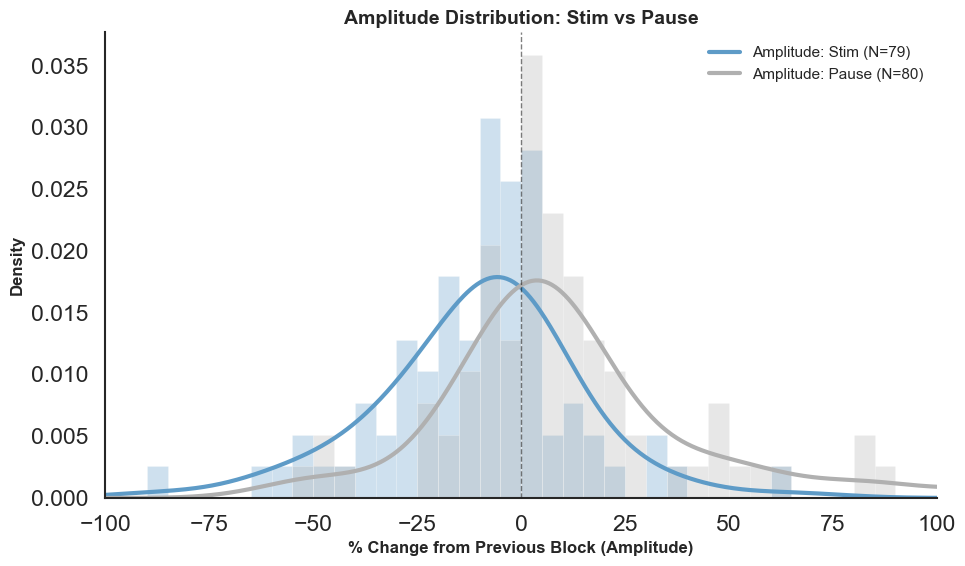

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def plot_amp_distribution_with_hist(df_amp):
    """
    מצייר התפלגות אמפליטודה בלבד: KDE + היסטוגרמה (Bins).
    Stim: תכלת
    Pause: אפור
    """
    
    # הגדרת קונפיגורציה לאמפליטודה בלבד
    configs = [
        (df_amp, 'stim', '#5e9bc7', 'Amplitude: Stim'),  # תכלת
        (df_amp, 'pause', '#b0b0b0', 'Amplitude: Pause') # אפור
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    for df, bt, color, base_label in configs:
        # סינון נתונים
        subset = df[df['block_type'] == bt]['pct_change'].dropna().values
        
        if len(subset) < 2:
            continue
            
        n_obs = len(subset)
        final_label = f"{base_label} (N={n_obs})"
            
        # 1. ציור ההיסטוגרמה (Bins)
        # density=True מבטיח שקנה המידה יתאים ל-KDE
        ax.hist(subset, bins=np.arange(-100, 101, 5), density=True, 
                color=color, alpha=0.3, edgecolor='white', linewidth=0.5)
            
        # 2. חישוב וציור KDE
        kde = gaussian_kde(subset)
        x_grid = np.linspace(-100, 100, 500)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=3, label=final_label)

    # הגדרות צירים
    ax.set_xlim(-100, 100)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    ax.set_title('Amplitude Distribution: Stim vs Pause', fontsize=14, fontweight='bold')
    ax.set_xlabel('% Change from Previous Block (Amplitude)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    
    # עיצוב אסתטי
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    ax.legend(fontsize=11, frameon=False, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# הרצה עם ה-DataFrame של האמפליטודה
plot_amp_distribution_with_hist(df_amp_pct)

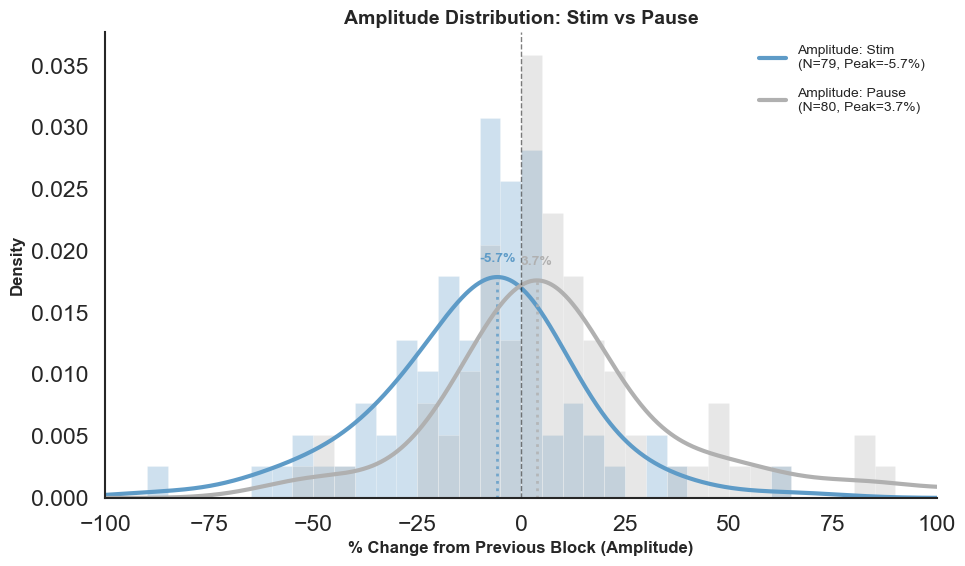

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def plot_amp_distribution_with_hist(df_amp):
    """
    מצייר התפלגות אמפליטודה: KDE + היסטוגרמה + סימון ערכי פיקים.
    """
    
    configs = [
        (df_amp, 'stim', '#5e9bc7', 'Amplitude: Stim'),  # תכלת
        (df_amp, 'pause', '#b0b0b0', 'Amplitude: Pause') # אפור
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    for df, bt, color, base_label in configs:
        # סינון נתונים
        subset = df[df['block_type'] == bt]['pct_change'].dropna().values
        
        if len(subset) < 2:
            continue
            
        n_obs = len(subset)
            
        # 1. ציור ההיסטוגרמה
        ax.hist(subset, bins=np.arange(-100, 101, 5), density=True, 
                color=color, alpha=0.3, edgecolor='white', linewidth=0.5)
            
        # 2. חישוב KDE
        kde = gaussian_kde(subset)
        x_grid = np.linspace(-100, 100, 1000) # רזולוציה גבוהה יותר למציאת פיק מדויק
        y_vals = kde(x_grid)
        
        # 3. מציאת הפיק (Peak)
        peak_idx = np.argmax(y_vals)
        peak_x = x_grid[peak_idx]
        peak_y = y_vals[peak_idx]
        
        # 4. ציור הקו והוספת הערך למקרא
        final_label = f"{base_label}\n(N={n_obs}, Peak={peak_x:.1f}%)"
        ax.plot(x_grid, y_vals, color=color, linewidth=3, label=final_label)
        
        # הוספת קו אנכי קטן במיקום הפיק
        ax.vlines(peak_x, 0, peak_y, color=color, linestyle=':', linewidth=2, alpha=0.8)
        
        # הוספת טקסט מעל הפיק בגרף
        ax.text(peak_x, peak_y + 0.001, f"{peak_x:.1f}%", 
                color=color, ha='center', va='bottom', fontsize=10, fontweight='bold')

    # הגדרות צירים
    ax.set_xlim(-100, 100)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    ax.set_title('Amplitude Distribution: Stim vs Pause', fontsize=14, fontweight='bold')
    ax.set_xlabel('% Change from Previous Block (Amplitude)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    
    # עיצוב אסתטי
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # עדכון המקרא שיופיע בצורה ברורה
    ax.legend(fontsize=10, frameon=False, loc='upper right', labelspacing=1.2)
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_amp_distribution_with_hist(df_amp_pct)

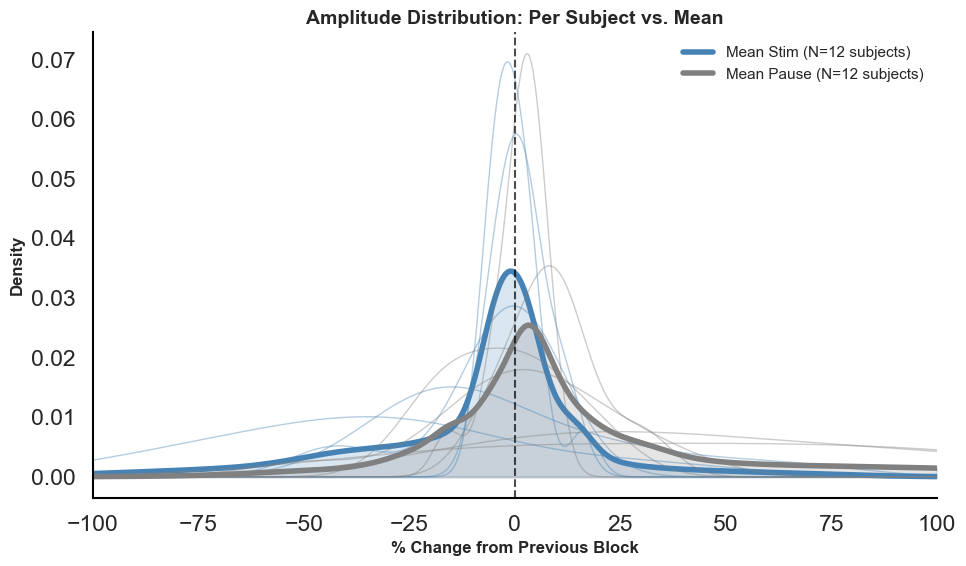

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def plot_subject_distributions_v2(df_amp):
    """
    גרף עם ניגודיות גבוהה יותר: 
    התפלגות אמפליטודה לכל נבדק (קווים ברורים יותר) וממוצע עבה.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_grid = np.linspace(-100, 100, 500)
    subjects = df_amp['Subject_ID'].unique()
    
    # צבעים עם ניגודיות משופרת
    color_stim = '#4682B4' # כחול פלדה (SteelBlue) - מעט כהה יותר מהתכלת הקודם
    color_pause = '#808080' # אפור בינוני (Gray) - בולט יותר על הלבן
    
    for bt, color, label in [('stim', color_stim, 'Stim'), ('pause', color_pause, 'Pause')]:
        all_kdes = []
        
        # 1. ציור קו לכל נבדק
        for s_id in subjects:
            subset = df_amp[(df_amp['Subject_ID'] == s_id) & (df_amp['block_type'] == bt)]['pct_change'].dropna().values
            
            if len(subset) > 5:
                kde = gaussian_kde(subset)
                y_vals = kde(x_grid)
                all_kdes.append(y_vals)
                
                # חיזוק הקווים האינדיבידואליים: alpha=0.4 במקום 0.2
                ax.plot(x_grid, y_vals, color=color, linewidth=1.0, alpha=0.4)
        
        # 2. חישוב וציור הממוצע
        if all_kdes:
            mean_kde = np.mean(all_kdes, axis=0)
            # קו ממוצע עבה במיוחד
            ax.plot(x_grid, mean_kde, color=color, linewidth=4, label=f'Mean {label} (N={len(subjects)} subjects)')
            # חיזוק הצללית: alpha=0.2 במקום 0.1
            ax.fill_between(x_grid, 0, mean_kde, color=color, alpha=0.2)

    # הגדרות גרף
    ax.set_xlim(-100, 100)
    # שינוי קו ה-0 לשחור ברור יותר
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
    
    ax.set_title('Amplitude Distribution: Per Subject vs. Mean', fontsize=14, fontweight='bold')
    ax.set_xlabel('% Change from Previous Block', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    
    # הפיכת מסגרת הגרף לכהה יותר
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    ax.legend(fontsize=11, frameon=False, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_subject_distributions_v2(df_amp_pct)

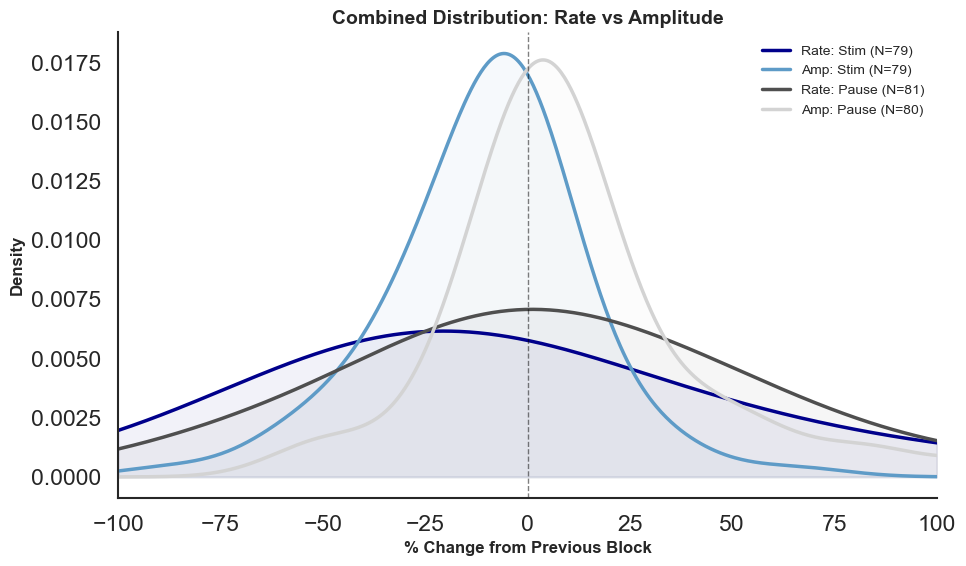

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def plot_combined_pct_distribution(df_rate, df_amp):
    """
    מצייר הפצת KDE של Rate ו-Amplitude עם ציון מספר התצפיות (N) במקרא.
    """
    
    # הגדרת הקונפיגורציות: (דאטה-פרייים, סוג בלוק, צבע, שם התופעה)
    configs = [
        (df_rate, 'stim', '#00008B', 'Rate: Stim'),     # כחול כהה
        (df_amp, 'stim', '#5e9bc7', 'Amp: Stim'),       # תכלת
        (df_rate, 'pause', '#4F4F4F', 'Rate: Pause'),   # אפור כהה
        (df_amp, 'pause', '#D3D3D3', 'Amp: Pause')      # אפור בהיר
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    for df, bt, color, base_label in configs:
        # סינון נתונים והסרת NaN
        subset = df[df['block_type'] == bt]['pct_change'].dropna().values
        
        if len(subset) < 2:
            continue
            
        # חישוב N - מספר התצפיות
        n_obs = len(subset)
        # יצירת לייבל מעודכן עם N
        final_label = f"{base_label} (N={n_obs})"
            
        # חישוב KDE
        kde = gaussian_kde(subset)
        x_grid = np.linspace(-100, 100, 500)
        
        # ציור הקו עם הלייבל החדש
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2.5, label=final_label)
        
        # מילוי עדין
        ax.fill_between(x_grid, 0, kde(x_grid), color=color, alpha=0.05)

    # הגדרות צירים
    ax.set_xlim(-100, 100)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    ax.set_title('Combined Distribution: Rate vs Amplitude', fontsize=14, fontweight='bold')
    ax.set_xlabel('% Change from Previous Block', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    
    # עיצוב
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # מיקום המקרא (Legend) בצד או למעלה כדי שלא יסתיר את הגרף
    ax.legend(fontsize=10, frameon=False, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_pct_distribution(df_rate_pct, df_amp_pct)

In [ ]:
# ── 5b-2  Paired Raincloud Plot (consecutive blocks) ─────────────
from scipy.stats import gaussian_kde as _gkde
from matplotlib.lines import Line2D

def _half_violin(ax, data_vals, centre, side='right',
                 color='gray', alpha=0.3, width=0.35):
    """Draw a half-violin (KDE) on one side of `centre`."""
    vals = np.asarray(data_vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) < 3:
        return
    kde = _gkde(vals)
    y_grid = np.linspace(vals.min(), vals.max(), 200)
    density = kde(y_grid)
    density = density / density.max() * width  # normalise to max width
    if side == 'right':
        ax.fill_betweenx(y_grid, centre, centre + density,
                         color=color, alpha=alpha, zorder=0)
    else:
        ax.fill_betweenx(y_grid, centre - density, centre,
                         color=color, alpha=alpha, zorder=0)


def plot_paired_raincloud(df_long, dv, label, model_result, title=''):
    """
    Raincloud-style paired plot for consecutive stim→pause blocks.
    • Half-violin distributions on each side (pure matplotlib)
    • Connecting lines coloured by direction (red=decrease, blue=increase)
    • Per-patient mean diamond markers
    """
    data = df_long[df_long['block_type'].isin(['stim', 'pause'])].copy()
    data = data.sort_values(['Subject_ID', 'block_number'])

    # Build stim→pause pairs
    pairs = []
    for subj, grp in data.groupby('Subject_ID'):
        grp = grp.sort_values('block_number')
        stim_rows = grp[grp['block_type'] == 'stim']
        for _, srow in stim_rows.iterrows():
            bn = srow['block_number']
            pause_row = grp[(grp['block_number'] == bn + 1) &
                            (grp['block_type'] == 'pause')]
            if not pause_row.empty:
                pairs.append({
                    'Subject_ID': subj,
                    'stim_val': srow[dv],
                    'pause_val': pause_row.iloc[0][dv],
                })

    pdf = pd.DataFrame(pairs)
    if pdf.empty:
        print(f'No pairs found for {label}')
        return

    fig, ax = plt.subplots(figsize=(7, 7))

    # ── Half-violins ──
    _half_violin(ax, pdf['stim_val'].values, centre=0, side='right',
                 color='#ce84ad', alpha=0.30, width=0.35)
    _half_violin(ax, pdf['pause_val'].values, centre=1, side='left',
                 color='#b0b0b0', alpha=0.30, width=0.35)

    # ── Box plots (narrow, matplotlib) ──
    bp_stim = ax.boxplot([pdf['stim_val'].dropna().values],
                         positions=[0], widths=0.14,
                         patch_artist=True, showmeans=True,
                         meanprops=dict(marker='D', markerfacecolor='white',
                                        markeredgecolor='black', markersize=6),
                         medianprops=dict(color='black', linewidth=1.5),
                         boxprops=dict(facecolor='#ce84ad', alpha=0.6,
                                       edgecolor='black'),
                         whiskerprops=dict(color='black'),
                         capprops=dict(color='black'),
                         showfliers=False, zorder=2)
    bp_pause = ax.boxplot([pdf['pause_val'].dropna().values],
                          positions=[1], widths=0.14,
                          patch_artist=True, showmeans=True,
                          meanprops=dict(marker='D', markerfacecolor='white',
                                         markeredgecolor='black', markersize=6),
                          medianprops=dict(color='black', linewidth=1.5),
                          boxprops=dict(facecolor='#b0b0b0', alpha=0.6,
                                        edgecolor='black'),
                          whiskerprops=dict(color='black'),
                          capprops=dict(color='black'),
                          showfliers=False, zorder=2)

    # ── Connecting lines: red = decrease, blue = increase ──
    color_down = '#D32F2F'  # red
    color_up   = '#1976D2'  # blue
    np.random.seed(42)
    jitter = np.random.uniform(-0.06, 0.06, len(pdf))
    for i_row, (_, row) in enumerate(pdf.iterrows()):
        delta = row['pause_val'] - row['stim_val']
        lc = color_down if delta < 0 else color_up
        ax.plot([0 + jitter[i_row], 1 + jitter[i_row]],
                [row['stim_val'], row['pause_val']],
                color=lc, alpha=0.45, linewidth=0.9, zorder=1)

    # ── Individual points ──
    stim_x  = np.zeros(len(pdf)) + jitter
    pause_x = np.ones(len(pdf))  + jitter
    ax.scatter(stim_x,  pdf['stim_val'],  s=22, c='#ce84ad',
               edgecolors='black', linewidth=0.3, alpha=0.7, zorder=3)
    ax.scatter(pause_x, pdf['pause_val'], s=22, c='#b0b0b0',
               edgecolors='black', linewidth=0.3, alpha=0.7, zorder=3)

    # ── Per-patient mean markers ──
    patient_means = pdf.groupby('Subject_ID')[['stim_val', 'pause_val']].mean()
    ax.scatter(np.full(len(patient_means), -0.22),
               patient_means['stim_val'],
               marker='D', s=55, c='#8B0A50', edgecolors='black',
               linewidth=0.6, zorder=4, label='Patient mean')
    ax.scatter(np.full(len(patient_means), 1.22),
               patient_means['pause_val'],
               marker='D', s=55, c='#555555', edgecolors='black',
               linewidth=0.6, zorder=4)

    # ── Title, labels, legend ──
    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\nStim coef = {coef:.2f}%, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Stim', 'Pause'], fontsize=12)
    ax.set_ylabel(f'{label}', fontsize=12, fontweight='bold')
    legend_elements = [
        Line2D([0], [0], color=color_up,   lw=1.5, label='Increase (stim→pause)'),
        Line2D([0], [0], color=color_down,  lw=1.5, label='Decrease (stim→pause)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#8B0A50',
               markersize=7, markeredgecolor='black', label='Patient mean'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_paired_raincloud(df_rate, 'firing_rate', 'Firing Rate',
                      rate_m3['3B'],
                      'Firing Rate – Paired Stim→Pause (raw values)')

plot_paired_raincloud(df_amp, 'amplitude', 'Amplitude',
                      amp_m3['3B'],
                      'Amplitude – Paired Stim→Pause (raw values)')


In [ ]:
# ── 5b-3  Cumulative % Change Trajectory ─────────────────────────
def plot_cumulative_pct(df_pct, label, title=''):
    """
    Per-subject cumulative sum of pct_change across blocks.
    Colour each point by block type; overlay group-mean trend.
    Pure matplotlib to avoid seaborn OptionError.
    """
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    data = data.sort_values(['Subject_ID', 'block_number'])
    data['cum_pct'] = data.groupby('Subject_ID')['pct_change'].cumsum()

    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

    fig, ax = plt.subplots(figsize=(10, 5))

    for subj, grp in data.groupby('Subject_ID'):
        ax.plot(grp['block_number'], grp['cum_pct'],
                color='#888888', alpha=0.35, linewidth=0.8, zorder=1)
        for bt, color in palette.items():
            sub = grp[grp['block_type'] == bt]
            ax.scatter(sub['block_number'], sub['cum_pct'],
                       c=color, s=22, edgecolors='none', alpha=0.6, zorder=2)

    # Group means
    for bt, color in palette.items():
        means = data[data['block_type'] == bt].groupby('block_number')['cum_pct'].mean()
        ax.plot(means.index, means.values, color=color,
                linewidth=2.5, marker='o', markersize=5,
                label=bt.capitalize() + ' mean', zorder=3)

    ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=0)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Block Number', fontsize=13)
    ax.set_ylabel(f'Cumulative % Change ({label})',
                  fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_cumulative_pct(df_rate_pct, 'Firing Rate',
                    'Firing Rate – Cumulative % Change Over Time')

plot_cumulative_pct(df_amp_pct, 'Amplitude',
                    'Amplitude – Cumulative % Change Over Time')


---
## 5c. Model 3B – Extra Amplitude Visualizations

Four additional ways to examine the **amplitude** Model 3B result
(significant stim vs pause difference in consecutive-block % change):

1. **Subject-level Forest Plot** – per-subject mean pct-change difference
   (stim − pause) with bootstrapped 95 % CIs, plus the overall model estimate.
2. **Heatmap** – Subject × Block pct-change matrix, coloured by magnitude,
   with block-type annotations along the top.
3. **Spaghetti Plot** – raw amplitude trajectories per subject with
   alternating stim / pause background shading.
4. **Bland–Altman (mean-difference) plot** – per-subject mean vs difference
   of stim / pause pct-change, to detect systematic bias.

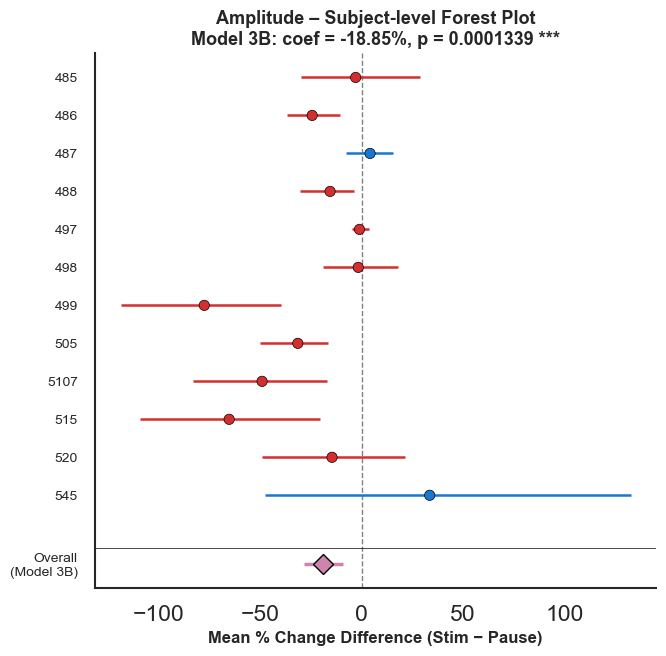

In [38]:
# ── 5c-1  Subject-level Forest Plot (Amplitude) ──────────────────
def plot_forest_amplitude(df_pct, model_result):
    """
    For each subject, compute mean pct_change for stim and pause,
    then plot the difference (stim - pause) with bootstrapped 95% CI.
    The overall model estimate is shown as a diamond at the bottom.
    Pure matplotlib + numpy bootstrap.
    """
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()

    subjects = sorted(data['Subject_ID'].unique())
    diffs, ci_lows, ci_highs = [], [], []

    np.random.seed(0)
    for subj in subjects:
        s = data[(data['Subject_ID'] == subj) & (data['block_type'] == 'stim')]['pct_change'].values
        p = data[(data['Subject_ID'] == subj) & (data['block_type'] == 'pause')]['pct_change'].values
        if len(s) == 0 or len(p) == 0:
            diffs.append(np.nan); ci_lows.append(np.nan); ci_highs.append(np.nan)
            continue
        obs_diff = s.mean() - p.mean()
        # bootstrap 95% CI of difference
        boot_diffs = []
        for _ in range(2000):
            bs = np.random.choice(s, size=len(s), replace=True)
            bp = np.random.choice(p, size=len(p), replace=True)
            boot_diffs.append(bs.mean() - bp.mean())
        boot_diffs = np.array(boot_diffs)
        ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
        diffs.append(obs_diff); ci_lows.append(ci_lo); ci_highs.append(ci_hi)

    diffs = np.array(diffs)
    ci_lows = np.array(ci_lows)
    ci_highs = np.array(ci_highs)

    fig, ax = plt.subplots(figsize=(7, max(5, len(subjects) * 0.45 + 1.5)))
    y_pos = np.arange(len(subjects))

    # Plot each subject
    colours = ['#D32F2F' if d < 0 else '#1976D2' for d in diffs]
    ax.hlines(y_pos, ci_lows, ci_highs, colors=colours, linewidth=1.8, zorder=2)
    ax.scatter(diffs, y_pos, c=colours, s=55, edgecolors='black',
               linewidth=0.5, zorder=3)

    # Overall model estimate
    coef = model_result.fe_params.get('is_stim', np.nan)
    p_val = model_result.pvalues.get('is_stim', np.nan)
    ci = model_result.conf_int()
    model_ci = ci.loc['is_stim'] if 'is_stim' in ci.index else [np.nan, np.nan]
    y_model = len(subjects) + 0.8
    ax.axhline(y_model - 0.4, color='black', linewidth=0.5, linestyle='-')
    ax.plot(coef, y_model, marker='D', markersize=10, color='#ce84ad',
            markeredgecolor='black', markeredgewidth=1, zorder=4)
    ax.hlines(y_model, model_ci[0], model_ci[1], colors='#ce84ad',
              linewidth=2.5, zorder=3)

    ax.axvline(0, color='gray', linewidth=1, linestyle='--', zorder=1)

    ax.set_yticks(list(y_pos) + [y_model])
    ax.set_yticklabels([str(s) for s in subjects] + ['Overall\n(Model 3B)'],
                       fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Mean % Change Difference (Stim − Pause)',
                  fontsize=12, fontweight='bold')
    ax.set_title(f'Amplitude – Subject-level Forest Plot\n'
                 f'Model 3B: coef = {coef:.2f}%, p = {p_val:.4g} {p_to_stars(p_val)}',
                 fontsize=13, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_forest_amplitude(df_amp_pct, amp_m3['3B'])


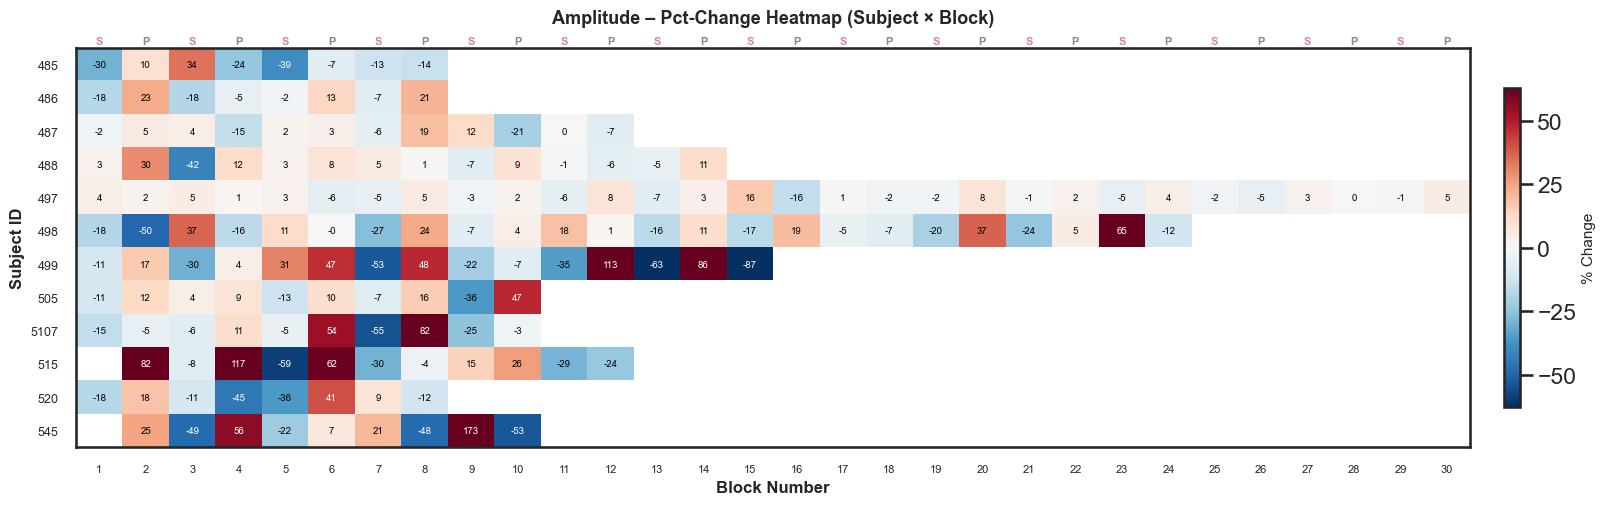

In [39]:
# ── 5c-2  Pct-Change Heatmap: Subject × Block (Amplitude) ────────
def plot_pct_heatmap(df_pct, label, title=''):
    """
    Heatmap of pct_change values: rows = subjects, columns = block numbers.
    Block type (stim / pause) annotated along the top edge.
    Pure matplotlib (imshow).
    """
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    pivot = data.pivot_table(index='Subject_ID', columns='block_number',
                             values='pct_change', aggfunc='mean')
    pivot = pivot.sort_index()

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 0.6),
                                    max(4, len(pivot.index) * 0.45)))

    # Symmetric colour limits centred on 0
    vmax = np.nanpercentile(np.abs(pivot.values), 95)
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, interpolation='nearest')

    # Axis labels
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(s) for s in pivot.index], fontsize=9)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(c)) for c in pivot.columns],
                       fontsize=8, rotation=0)
    ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Subject ID', fontsize=12, fontweight='bold')

    # Annotate block type along top
    block_types = data.drop_duplicates('block_number').set_index('block_number')['block_type']
    for j, bn in enumerate(pivot.columns):
        bt = block_types.get(bn, '?')
        colour = '#ce84ad' if bt == 'stim' else '#888888'
        ax.text(j, -0.7, 'S' if bt == 'stim' else 'P',
                ha='center', va='center', fontsize=8,
                fontweight='bold', color=colour)

    # Annotate cell values
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                txt_col = 'white' if abs(val) > vmax * 0.6 else 'black'
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=7, color=txt_col)

    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('% Change', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=18)
    plt.tight_layout()
    plt.show()


plot_pct_heatmap(df_amp_pct, 'Amplitude',
                 'Amplitude – Pct-Change Heatmap (Subject × Block)')


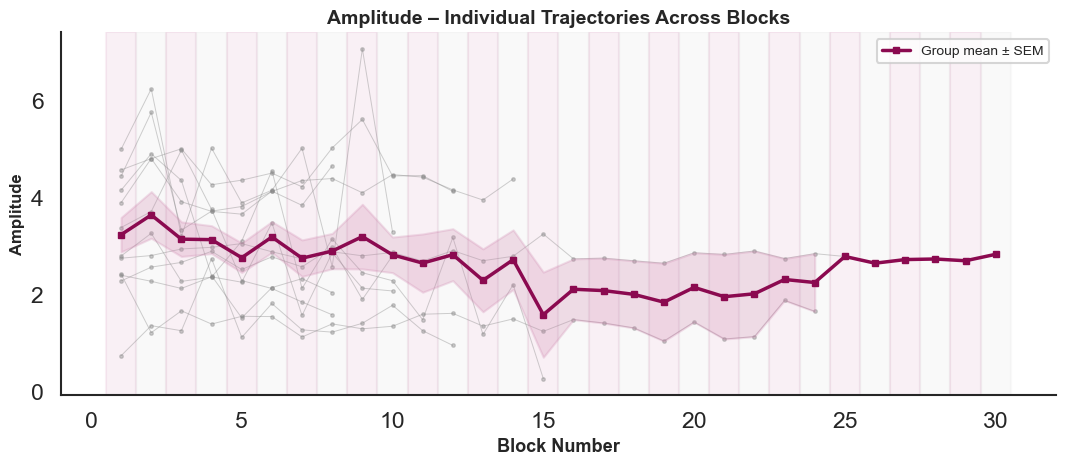

In [40]:
# ── 5c-3  Spaghetti Plot with Stim/Pause Shading (Amplitude) ─────
def plot_spaghetti(df_long, dv, label, title=''):
    """
    Individual subject amplitude trajectories across all blocks,
    with alternating background shading for stim (pink) and pause (gray).
    Group mean ± SEM overlaid as a thick line with error band.
    """
    data = df_long[df_long['block_type'].isin(['stim', 'pause'])].copy()
    data = data.sort_values(['Subject_ID', 'block_number'])

    fig, ax = plt.subplots(figsize=(11, 5))

    # Alternating background shading
    block_info = (data[['block_number', 'block_type']]
                  .drop_duplicates()
                  .sort_values('block_number'))
    for _, row in block_info.iterrows():
        bn = row['block_number']
        clr = '#ce84ad' if row['block_type'] == 'stim' else '#d0d0d0'
        ax.axvspan(bn - 0.5, bn + 0.5, color=clr, alpha=0.12, zorder=0)

    # Individual subject lines
    for subj, grp in data.groupby('Subject_ID'):
        grp = grp.sort_values('block_number')
        ax.plot(grp['block_number'], grp[dv],
                color='#888888', alpha=0.4, linewidth=0.7,
                marker='o', markersize=2.5, zorder=1)

    # Group mean ± SEM
    gmean = data.groupby('block_number')[dv].mean()
    gsem  = data.groupby('block_number')[dv].sem()
    ax.fill_between(gmean.index, gmean - gsem, gmean + gsem,
                    color='#ce84ad', alpha=0.25, zorder=2)
    ax.plot(gmean.index, gmean.values, color='#8B0A50',
            linewidth=2.5, marker='s', markersize=5,
            label='Group mean ± SEM', zorder=3)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Block Number', fontsize=13, fontweight='bold')
    ax.set_ylabel(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_spaghetti(df_amp, 'amplitude', 'Amplitude',
               'Amplitude – Individual Trajectories Across Blocks')


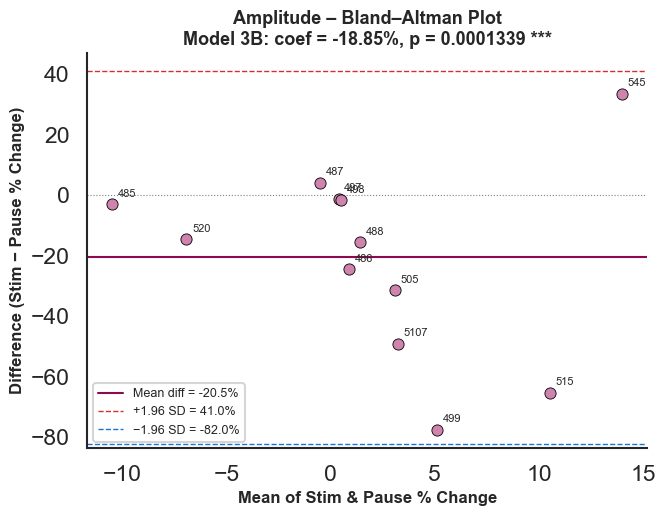

In [41]:
# ── 5c-4  Bland–Altman (Mean-Difference) Plot (Amplitude) ────────
def plot_bland_altman(df_pct, model_result, title=''):
    """
    For each subject, compute mean pct_change during stim and pause.
    Plot the average of both against their difference (stim - pause).
    Limits of agreement (mean diff ± 1.96 SD) are shown.
    """
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    subj_means = data.groupby(['Subject_ID', 'block_type'])['pct_change'].mean().unstack()
    subj_means = subj_means.dropna()

    avg  = (subj_means['stim'] + subj_means['pause']) / 2
    diff = subj_means['stim'] - subj_means['pause']

    mean_diff = diff.mean()
    sd_diff   = diff.std()

    fig, ax = plt.subplots(figsize=(7, 5.5))

    ax.scatter(avg, diff, s=65, c='#ce84ad', edgecolors='black',
               linewidth=0.6, zorder=3)

    # Label each point
    for subj in subj_means.index:
        ax.annotate(str(subj), (avg[subj], diff[subj]),
                    fontsize=8, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

    # Reference lines
    ax.axhline(mean_diff, color='#8B0A50', linewidth=1.5, linestyle='-',
               label=f'Mean diff = {mean_diff:.1f}%', zorder=2)
    ax.axhline(mean_diff + 1.96 * sd_diff, color='#D32F2F',
               linewidth=1, linestyle='--',
               label=f'+1.96 SD = {mean_diff + 1.96*sd_diff:.1f}%', zorder=2)
    ax.axhline(mean_diff - 1.96 * sd_diff, color='#1976D2',
               linewidth=1, linestyle='--',
               label=f'−1.96 SD = {mean_diff - 1.96*sd_diff:.1f}%', zorder=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':', zorder=1)

    p = model_result.pvalues.get('is_stim', np.nan)
    coef = model_result.fe_params.get('is_stim', np.nan)
    ax.set_title(f'{title}\n'
                 f'Model 3B: coef = {coef:.2f}%, p = {p:.4g} {p_to_stars(p)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean of Stim & Pause % Change',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel('Difference (Stim − Pause % Change)',
                  fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_bland_altman(df_amp_pct, amp_m3['3B'],
                  'Amplitude – Bland–Altman Plot')


---
## 6. Per-Patient Correlation: Rate Reduction vs Amplitude Reduction During Stim

For each subject, compute the **mean difference** (stim − pause) for both firing rate and amplitude.
A negative value means stim reduced the measure relative to pause.
Then test whether subjects who show a larger rate reduction also show a larger amplitude reduction.

In [19]:
from scipy.stats import pearsonr, spearmanr

# -- Compute per-subject stim effect (stim mean - pause mean) ----
def per_subject_stim_effect(df, dv):
    """For each subject, return mean(stim) - mean(pause)."""
    sp = df[df["block_type"].isin(["stim", "pause"])].copy()
    means = sp.groupby(["Subject_ID", "block_type"])[dv].mean().unstack("block_type")
    means["diff"] = means["stim"] - means["pause"]
    return means[["stim", "pause", "diff"]]


rate_effect = per_subject_stim_effect(df_rate, "firing_rate")
amp_effect  = per_subject_stim_effect(df_amp,  "amplitude")

# merge on Subject_ID
corr_df = pd.DataFrame({
    "rate_diff": rate_effect["diff"],
    "amp_diff":  amp_effect["diff"],
}).dropna()

print(f"Subjects with both measures: {len(corr_df)}")
display(corr_df)

Subjects with both measures: 12


,rate_diff,amp_diff
Subject_ID,,
485,-0.803052,0.329796
486,0.014203,-0.500973
487,-1.337680,0.174838
488,0.386237,-0.372258
497,-8.145990,-0.018139
498,0.236042,0.052843
499,0.167657,-1.039240
505,0.158625,-0.416379
5107,0.011967,-0.514692


In [20]:
# -- Correlations -------------------------------------------------------
r_pearson,  p_pearson  = pearsonr(corr_df["rate_diff"],  corr_df["amp_diff"])
r_spearman, p_spearman = spearmanr(corr_df["rate_diff"], corr_df["amp_diff"])

print(f"Pearson  r = {r_pearson:.3f},  p = {p_pearson:.4g}")
print(f"Spearman rho = {r_spearman:.3f},  p = {p_spearman:.4g}")

Pearson  r = -0.168,  p = 0.6015
Spearman rho = -0.112,  p = 0.7292


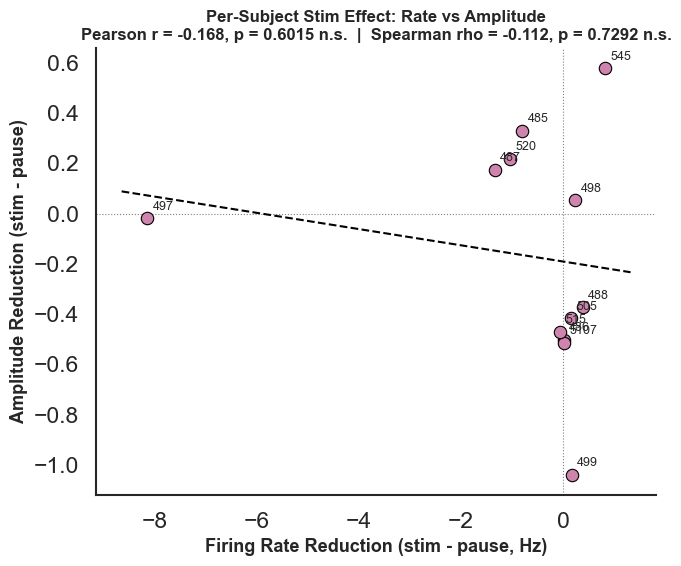

In [21]:
# -- Scatter plot -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(corr_df["rate_diff"], corr_df["amp_diff"],
           s=80, c="#ce84ad", edgecolors="black", linewidth=0.8, zorder=3)

# label each point with Subject_ID
for subj, row in corr_df.iterrows():
    ax.annotate(subj, (row["rate_diff"], row["amp_diff"]),
                fontsize=9, ha="left", va="bottom",
                xytext=(4, 4), textcoords="offset points")

# regression line
m, b = np.polyfit(corr_df["rate_diff"], corr_df["amp_diff"], 1)
x_line = np.linspace(corr_df["rate_diff"].min() - 0.5,
                     corr_df["rate_diff"].max() + 0.5, 100)
ax.plot(x_line, m * x_line + b, color="black",
        linewidth=1.5, linestyle="--", zorder=2)

# reference lines at zero
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":", zorder=1)
ax.axvline(0, color="gray", linewidth=0.8, linestyle=":", zorder=1)

ax.set_xlabel("Firing Rate Reduction (stim - pause, Hz)",
              fontsize=13, fontweight="bold")
ax.set_ylabel("Amplitude Reduction (stim - pause)",
              fontsize=13, fontweight="bold")
ax.set_title(
    f"Per-Subject Stim Effect: Rate vs Amplitude\n"
    f"Pearson r = {r_pearson:.3f}, p = {p_pearson:.4g} {p_to_stars(p_pearson)}  |  "
    f"Spearman rho = {r_spearman:.3f}, p = {p_spearman:.4g} {p_to_stars(p_spearman)}",
    fontsize=12, fontweight="bold")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.tight_layout()
plt.show()

---
## 7. Summary Table

In [22]:
def extract_summary_row(model_id, measure, result, key_coef):
    """Extract one row for the summary table."""
    coef = result.fe_params.get(key_coef, np.nan)
    p = result.pvalues.get(key_coef, np.nan)
    ci = result.conf_int().loc[key_coef] if key_coef in result.conf_int().index else [np.nan, np.nan]
    return {
        'Model': model_id,
        'Measure': measure,
        'Coefficient': key_coef,
        'Estimate': round(coef, 4),
        'p-value': round(p, 4),
        'Sig.': p_to_stars(p),
        'CI_low': round(ci[0], 4) if not np.isnan(ci[0]) else np.nan,
        'CI_high': round(ci[1], 4) if not np.isnan(ci[1]) else np.nan,
        'N_obs': int(result.nobs),
    }

rows = []

# Model 1
rows.append(extract_summary_row('1A: Stim vs Non-Stim', 'Rate', rate_m1['1A'], 'is_stim'))
rows.append(extract_summary_row('1A: Stim vs Non-Stim', 'Amp',  amp_m1['1A'],  'is_stim'))
rows.append(extract_summary_row('1B: Stim vs Pause',    'Rate', rate_m1['1B'], 'is_stim'))
rows.append(extract_summary_row('1B: Stim vs Pause',    'Amp',  amp_m1['1B'],  'is_stim'))

# Model 2
rows.append(extract_summary_row('2A: Time Trend',       'Rate', rate_m2['2A'], 'block_number'))
rows.append(extract_summary_row('2A: Time Trend',       'Amp',  amp_m2['2A'],  'block_number'))
rows.append(extract_summary_row('2B: Time × Type',      'Rate', rate_m2['2B'], 'block_number:is_stim'))
rows.append(extract_summary_row('2B: Time × Type',      'Amp',  amp_m2['2B'],  'block_number:is_stim'))

# Model 3
rows.append(extract_summary_row('3A: Pct Change ≠ 0',   'Rate', rate_m3['3A'], 'Intercept'))
rows.append(extract_summary_row('3A: Pct Change ≠ 0',   'Amp',  amp_m3['3A'],  'Intercept'))
rows.append(extract_summary_row('3B: Pct Stim vs Pause','Rate', rate_m3['3B'], 'is_stim'))
rows.append(extract_summary_row('3B: Pct Stim vs Pause','Amp',  amp_m3['3B'],  'is_stim'))

df_summary = pd.DataFrame(rows)
display(df_summary)

,Model,Measure,Coefficient,Estimate,p-value,Sig.,CI_low,CI_high,N_obs
0,1A: Stim vs Non-Stim,Rate,is_stim,-1.8031,0.0088,**,-3.1530,-0.4531,172
1,1A: Stim vs Non-Stim,Amp,is_stim,-0.2358,0.0273,*,-0.4453,-0.0264,171
2,1B: Stim vs Pause,Rate,is_stim,-1.5553,0.0216,*,-2.8822,-0.2284,162
3,1B: Stim vs Pause,Amp,is_stim,-0.1661,0.1194,n.s.,-0.3751,0.0429,161
4,2A: Time Trend,Rate,block_number,-0.1354,0.0298,*,-0.2575,-0.0133,172
5,2A: Time Trend,Amp,block_number,-0.0290,0.0023,**,-0.0476,-0.0103,171
6,2B: Time × Type,Rate,block_number:is_stim,-0.3388,0.0004,***,-0.5274,-0.1502,162
7,2B: Time × Type,Amp,block_number:is_stim,0.0081,0.6094,n.s.,-0.0229,0.0390,161
8,3A: Pct Change ≠ 0,Rate,Intercept,16.4940,0.0440,*,0.4407,32.5472,160
9,3A: Pct Change ≠ 0,Amp,Intercept,1.6600,0.5175,n.s.,-3.3668,6.6867,159


In [ ]:
# Save summary to CSV
df_summary.to_csv('hierarchical_models_summary.csv', index=False)
print('Summary saved to hierarchical_models_summary.csv')